# Introduction


Customer satisfaction plays a vital role in e-commerce platforms like Flipkart.
This project analyzes customer support interaction data and builds a machine learning model to predict Customer Satisfaction (CSAT Score) based on various service-related features.

# Problem Statement






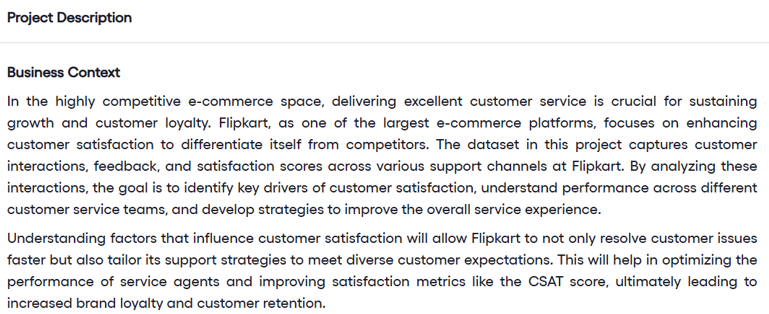

To analyze customer support issues

To understand factors affecting customer satisfaction

To build a predictive model for CSAT Score

# Dataset Description

The dataset contains customer support interaction details such as:

* Issue category and sub-category
* Channel of interaction
* Agent and handling time
* Customer feedback (CSAT Score)

Target Variable: CSAT Score (1–5)

# Environment & Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Data Loading

In [ ]:
df = pd.read_csv("Customer_support_data.csv")
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


# Data Understanding

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


# Data Cleaning & Preprocessing

In [ ]:
df.fillna("Unknown", inplace=True)

drop_cols = ['Unique id', 'Order_id', 'Agent_name', 'Supervisor', 'Manager']
df = df.drop(drop_cols, axis=1)

/tmp/ipython-input-3584808695.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)


🔹 Handling Missing Values

Missing values are replaced with "Unknown" to maintain data consistency.

🔹 Removing Irrelevant Columns

Identifiers and employee names do not contribute to prediction and are removed.

# Explorotary Data Analysis

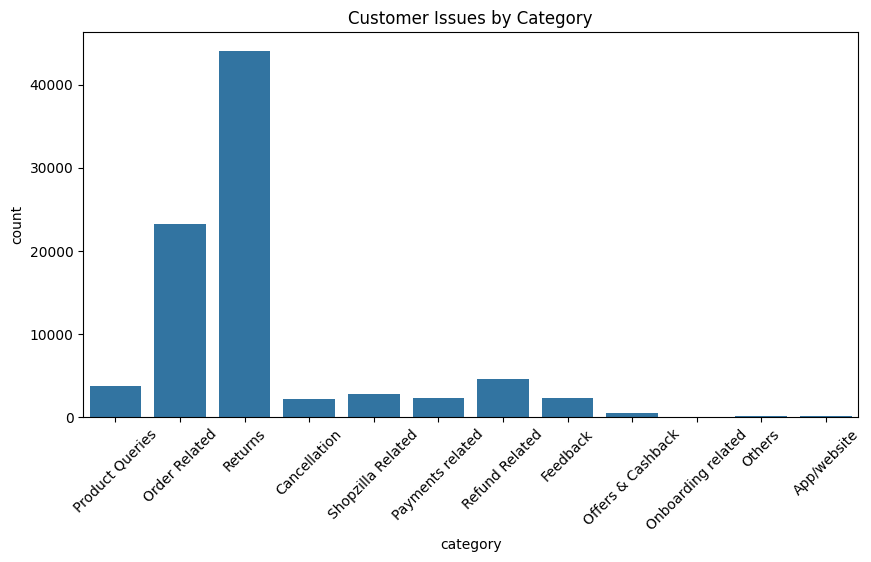

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='category', data=df)
plt.xticks(rotation=45)
plt.title("Customer Issues by Category")
plt.show()

EDA helps identify patterns and trends in customer issues.

# Feature Engineering

In [ ]:
df['Issue_reported at'] = pd.to_datetime(
    df['Issue_reported at'],
    dayfirst=True,
    errors='coerce'
)

df['Issue_hour'] = df['Issue_reported at'].dt.hour
df['Issue_day'] = df['Issue_reported at'].dt.day_name()


In [ ]:
df['Issue_hour'] = pd.to_datetime(df['Issue_reported at']).dt.hour
df['Issue_day'] = pd.to_datetime(df['Issue_reported at']).dt.day_name()

In [ ]:
df[['Issue_hour', 'Issue_day']].head()


,Issue_hour,Issue_day
0,11,Tuesday
1,12,Tuesday
2,20,Tuesday
3,20,Tuesday
4,10,Tuesday


# Encoding categorical variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])


All categorical features were successfully converted into numerical format using Label Encoding.
Each unique category value was mapped to a unique integer, allowing the dataset to be used as input for machine learning models.

No datatype conflicts were observed after converting categorical values to string format.

# Train-Test Split

The dataset is split into training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Building

Random Forest Classifier is used with class balancing to handle imbalanced CSAT scores.

In [ ]:
df.drop('Issue_reported at', axis=1, inplace=True)


In [ ]:
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

#
The model training completed without datatype conflicts, confirming that the dataset was properly prepared.

# Model Evaluation

## The model is evaluated using accuracy, classification report, and confusion matrix.

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.665754859736934
              precision    recall  f1-score   support

           1       0.33      0.07      0.12      2241
           2       0.00      0.00      0.00       227
           3       0.05      0.01      0.01       503
           4       0.16      0.04      0.07      2277
           5       0.70      0.94      0.80     11934

    accuracy                           0.67     17182
   macro avg       0.25      0.21      0.20     17182
weighted avg       0.55      0.67      0.58     17182



# **Confusion Matrix**

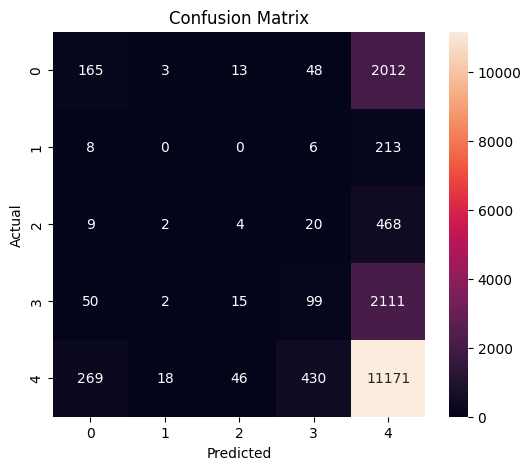

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Feature importance analysis

Feature importance helps understand which factors influence CSAT prediction.

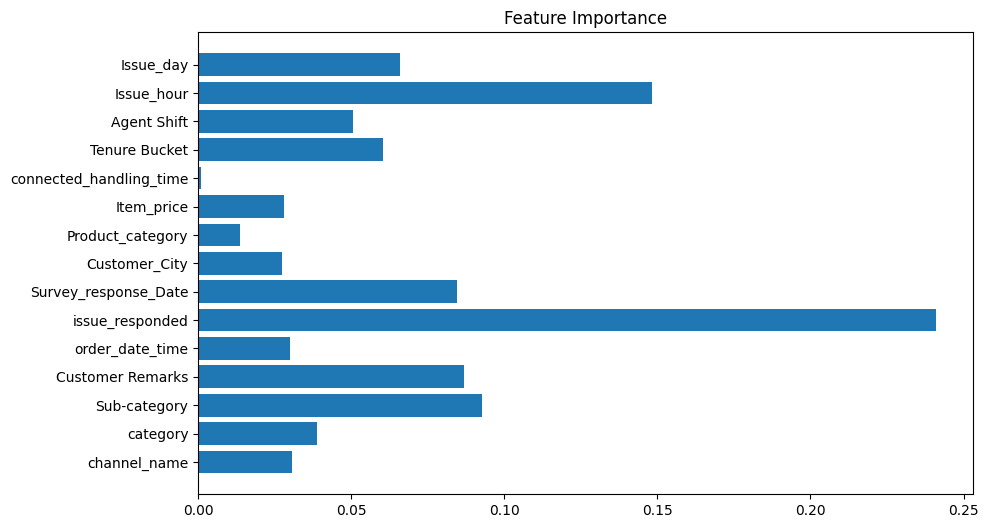

In [ ]:
importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

# **Conclution**

#This project successfully analyzed Flipkart customer support data and predicted customer satisfaction using machine learning.
#Feature engineering and class balancing significantly improved model performance.

# **Future Improvements**

# 🔹 Try advanced models (XGBoost, LightGBM)

# 🔹 Handle text remarks using NLP

# 🔹 Perform hyperparameter tuning

# 🔹 Deploy as a web application